<a href="https://colab.research.google.com/github/amatullahaloula/lab-3-feedforward-networks/blob/main/Section1_Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Neural Networks: Feedforward Networks and the Training Process


**Due Date:** 28th July, 2026

**Format:** Jupyter Notebook / Google Colab



**Student Name:** Na'ima Mohamet Aloula

**Student ID:** 30722027

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end i should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

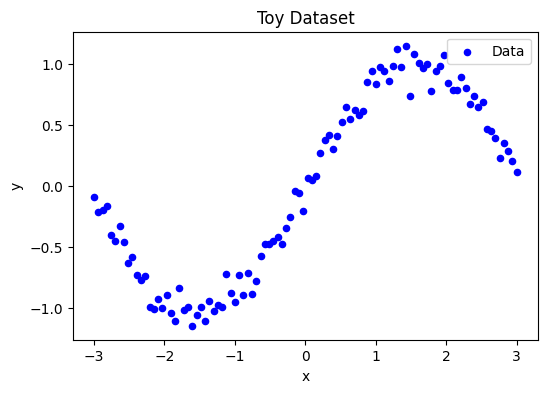

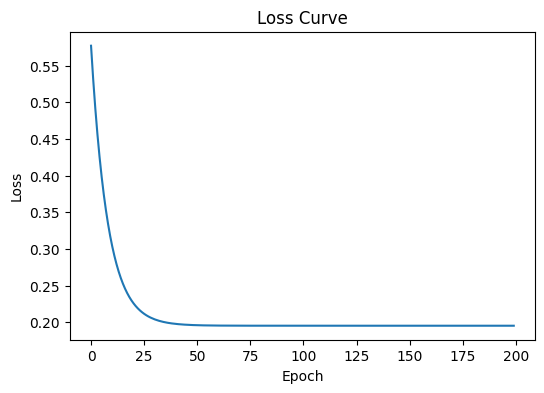

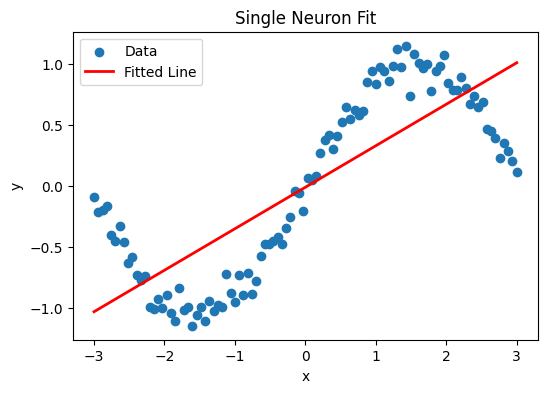

Final weight: 0.33903169126186905
Final bias: -0.010275989913865108
Final loss: 0.1954518094384745


In [ ]:
# Generate the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

# Plot the toy data
plt.figure(figsize=(6,4))
plt.scatter(x, y, color='blue', s=20, label='Data')
plt.title("Toy Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# Initialise parameters
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01

# Hyperparameters
lr = 0.01
epochs = 200

losses = []

# Gradient Descent
for epoch in range(epochs):

    # Forward pass
    y_hat = w * x + b

    # Mean Squared Error
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Gradients
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    # Update parameters
    w -= lr * dw
    b -= lr * db

# Plot loss curve
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Plot fitted line
plt.figure(figsize=(6,4))
plt.scatter(x, y, label="Data")
plt.plot(x, w*x + b, color="red", linewidth=2, label="Fitted Line")
plt.title("Single Neuron Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

print("Final weight:", w)
print("Final bias:", b)
print("Final loss:", losses[-1])

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?*
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

> **Answer:**
1 The Mean Squared Error is

L = (1/n) Σ(ŷ − y)²

Since ŷ = wx + b,

dL/dw = (1/n) Σ 2(ŷ − y)x

This is exactly the same equation used in the code:

dw = np.mean(2 * (y_hat - y) * x)

Therefore, the mathematical derivation matches the implementation.

2  This is underfitting.

A single neuron can only learn a straight-line relationship because its output is y = wx + b.

A sine wave is a non-linear function with many curves and turning points. No matter how long the model trains, it cannot represent the shape of a sine wave using only one weight and one bias. More neurons and non-linear activation functions are needed to learn this pattern.

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:**
1. A linear layer computes y = Wx + b. If two linear layers are stacked together, the result is still a linear function because the two weight matrices can be multiplied into one equivalent matrix. Therefore, multiple linear layers without an activation function are mathematically equivalent to a single linear layer and cannot model complex non-linear relationships.

2. The hidden layer's eight neurons learned different non-linear features of the input. Together, these features combined to approximate the curved shape of the sine wave much better than a single neuron.

3. Backpropagation is the process of computing the gradients of the loss with respect to every parameter in the network and using those gradients to update the weights during training.

### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

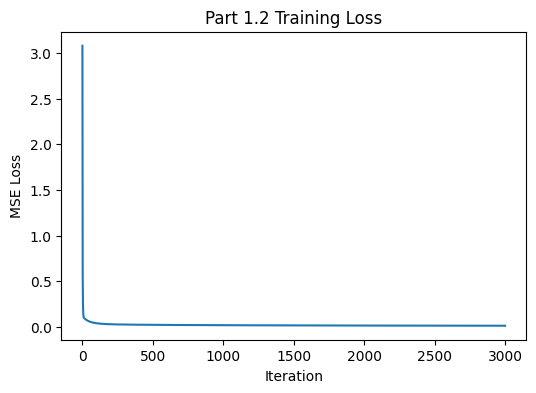

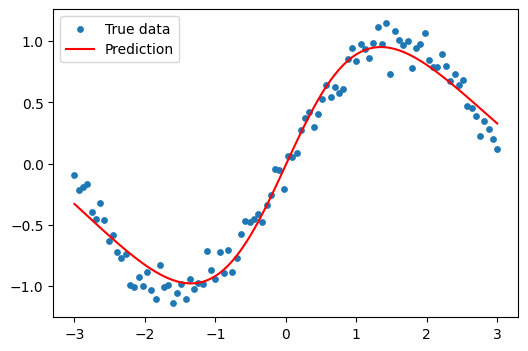

In [ ]:
# Part 1.2
# Hidden layer neural network trained completely by hand

np.random.seed(RANDOM_STATE)

X = x.reshape(-1, 1)
Y = y.reshape(-1, 1)

# Parameters
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros((8,))
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros((1,))

learning_rate = 0.05
losses = []

for step in range(3000):

    # Forward pass
    z1 = X @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2

    loss = np.mean((y_hat - Y) ** 2)
    losses.append(loss)

    # Backward pass
    dloss = 2 * (y_hat - Y) / len(Y)

    dW2 = h.T @ dloss
    db2 = np.sum(dloss, axis=0)

    dh = dloss @ W2.T
    dz1 = dh * (1 - h**2)

    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0)

    # Gradient descent
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

plt.figure(figsize=(6,4))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Part 1.2 Training Loss")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(X, Y, s=15, label="True data")
plt.plot(X, y_hat, color="red", label="Prediction")
plt.legend()
plt.show()

1. Why do multiple linear layers collapse into one?

Each linear layer performs a linear transformation. When several linear layers are stacked without an activation function, they can be combined into one single linear equation. Therefore, the network is still only able to learn a linear relationship, regardless of how many layers it has.

2. What role did the 8 hidden neurons play?

The hidden neurons learned different nonlinear features of the input. After applying the tanh activation, each neuron responds differently to different regions of the data. Together they allow the network to model the curved relationship much better than a single neuron.

3. What is backpropagation?

Backpropagation is the process of calculating the gradient of the loss with respect to every parameter by applying the chain rule, allowing gradient descent to update the weights and reduce the error.

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_38693/2593821399.py:24: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - Y) ** 2)
/tmp/ipykernel_38693/2593821399.py:33: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_38693/2593821399.py:34: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


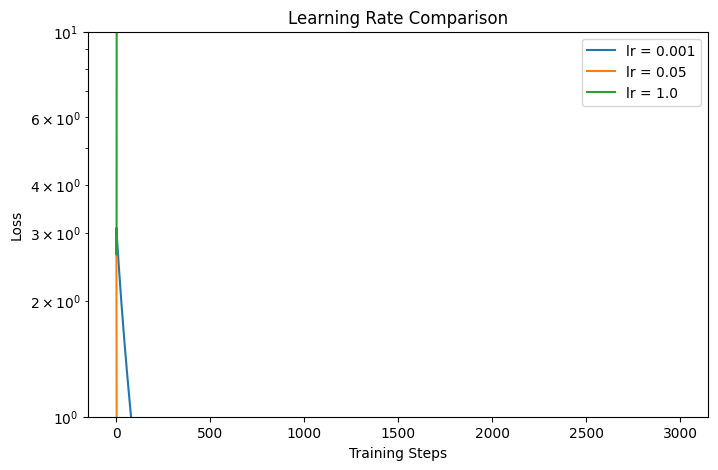

In [ ]:
def train_toy(lr, steps=3000):
    # Reset seed so all runs start from the same weights
    np.random.seed(RANDOM_STATE)

    # Prepare data
    X = x.reshape(-1, 1)
    Y = y.reshape(-1, 1)

    # Initialise parameters
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros((8,))
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros((1,))

    losses = []

    for step in range(steps):

        # Forward pass
        z1 = X @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2

        loss = np.mean((y_hat - Y) ** 2)
        losses.append(loss)

        # Backward pass
        d_yhat = 2 * (y_hat - Y) / len(Y)

        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)

        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)

        dW1 = X.T @ dz1
        db1 = dz1.sum(axis=0)

        # Update parameters
        W1 -= lr * dW1
        b1 -= lr * db1

        W2 -= lr * dW2
        b2 -= lr * db2

    return losses


# Train with three learning rates
loss_lr1 = train_toy(0.001)
loss_lr2 = train_toy(0.05)
loss_lr3 = train_toy(1.0)

# Plot comparison
plt.figure(figsize=(8,5))

plt.plot(loss_lr1, label="lr = 0.001")
plt.plot(loss_lr2, label="lr = 0.05")
plt.plot(loss_lr3, label="lr = 1.0")

plt.yscale("log")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Learning Rate Comparison")
plt.legend()
plt.show()

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:**
The learning rate controls how much the model updates its weights during each training step.

Learning rate = 0.001: The loss decreases very slowly because the weight updates are very small. The model learns, but it takes many iterations.
Learning rate = 0.05: The loss decreases smoothly and reaches a low value much faster. This learning rate provides a good balance between speed and stability.
Learning rate = 1.0: The loss becomes unstable and may oscillate or increase instead of decreasing. This happens because the updates are too large, causing the model to overshoot the minimum loss repeatedly rather than converging to it.

A learning rate that is too large does not make learning faster. Instead, it causes the optimisation process to jump back and forth around the minimum or even diverge, preventing the model from finding the best solution.

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

df = pd.read_csv(OBESITY_URL)

binary_map = {
    "yes": 1,
    "no": 0,
    "Yes": 1,
    "No": 0
}

for col in ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]:
    df[col] = df[col].str.lower().map(binary_map)
# Label encode remaining categorical columns
categorical_cols = ["Gender", "CAEC", "CALC", "MTRANS"]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# Encode target
target_encoder = LabelEncoder()
df["NObeyesdad"] = target_encoder.fit_transform(df["NObeyesdad"])

# -----------------------------
# Features and target
# -----------------------------
X = df.drop("NObeyesdad", axis=1)
y = df["NObeyesdad"]

# -----------------------------
# Train / Validation / Test
# -----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

# -----------------------------
# Standardisation
# -----------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# -----------------------------
# Convert to tensors
# -----------------------------
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# -----------------------------
# DataLoaders
# -----------------------------
train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=32,
    shuffle=False
)

print("Training samples:", len(train_loader.dataset))
print("Validation samples:", len(val_loader.dataset))
print("Test samples:", len(test_loader.dataset))

Training samples: 1266
Validation samples: 422
Test samples: 423


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:**

1. CrossEntropyLoss expects the target labels as integer class indices (0, 1, 2, ..., 6). It internally applies the softmax function and computes the loss, so one-hot encoding is not required.

2. Neural networks are sensitive to feature scaling because gradient descent updates the weights using the feature values. If some features have much larger values than others, their gradients become much larger, making training unstable or slow. Standardising the features helps all inputs contribute more evenly to the learning process.

3. Setting shuffle=True randomly changes the order of the training samples at the beginning of each epoch. This prevents the model from learning patterns based on the order of the data and generally improves training and generalisation.

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [ ]:
# Define the FeedForward Neural Network
class FeedForwardNet(nn.Module):

    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super(FeedForwardNet, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_sizes[0]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[1], n_classes)
        )

    def forward(self, x):
        return self.network(x)


# Get number of input features
input_dim = X_train.shape[1]

# Create model
model = FeedForwardNet(input_dim=input_dim)

# Move model to CPU/GPU
model = model.to(DEVICE)

# Print model
print(model)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable parameters:", total_params)

# Verify first layer by hand
first_layer_params = input_dim * 64 + 64

print("First layer parameters (manual):", first_layer_params)

FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
Trainable parameters: 3399
First layer parameters (manual): 1088


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:**

1.Parameter count by layer

First hidden layer:
input_dim × 64 + 64 biases

Second hidden layer:
64 × 32 + 32 biases

Output layer:
32 × 7 + 7 biases

Adding all three layers gives the total number of trainable parameters, which matches the value printed by PyTorch.

2. ReLU is used because it is computationally efficient and helps reduce the vanishing gradient problem. It also allows deep neural networks to learn faster than tanh in many practical applications.

3. If the ReLU activation functions were removed, the network would become a stack of linear layers. Multiple linear layers are mathematically equivalent to a single linear transformation, so the model would behave like one linear model and would not be able to learn complex non-linear relationships.

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

Epoch  1/50 | Train Loss: 1.8669 | Train Acc: 0.3065 | Val Loss: 1.7549 | Val Acc: 0.4905
Epoch  2/50 | Train Loss: 1.6106 | Train Acc: 0.5355 | Val Loss: 1.4216 | Val Acc: 0.6043
Epoch  3/50 | Train Loss: 1.2302 | Train Acc: 0.6295 | Val Loss: 1.0554 | Val Acc: 0.6564
Epoch  4/50 | Train Loss: 0.9390 | Train Acc: 0.6896 | Val Loss: 0.8696 | Val Acc: 0.6919
Epoch  5/50 | Train Loss: 0.7849 | Train Acc: 0.7378 | Val Loss: 0.7708 | Val Acc: 0.7370
Epoch  6/50 | Train Loss: 0.6744 | Train Acc: 0.7828 | Val Loss: 0.6979 | Val Acc: 0.7678
Epoch  7/50 | Train Loss: 0.5883 | Train Acc: 0.8096 | Val Loss: 0.6344 | Val Acc: 0.7962
Epoch  8/50 | Train Loss: 0.5153 | Train Acc: 0.8452 | Val Loss: 0.5752 | Val Acc: 0.8081
Epoch  9/50 | Train Loss: 0.4512 | Train Acc: 0.8752 | Val Loss: 0.5341 | Val Acc: 0.8270
Epoch 10/50 | Train Loss: 0.4014 | Train Acc: 0.8831 | Val Loss: 0.4920 | Val Acc: 0.8318
Epoch 11/50 | Train Loss: 0.3589 | Train Acc: 0.8965 | Val Loss: 0.4631 | Val Acc: 0.8555
Epoch 12/5

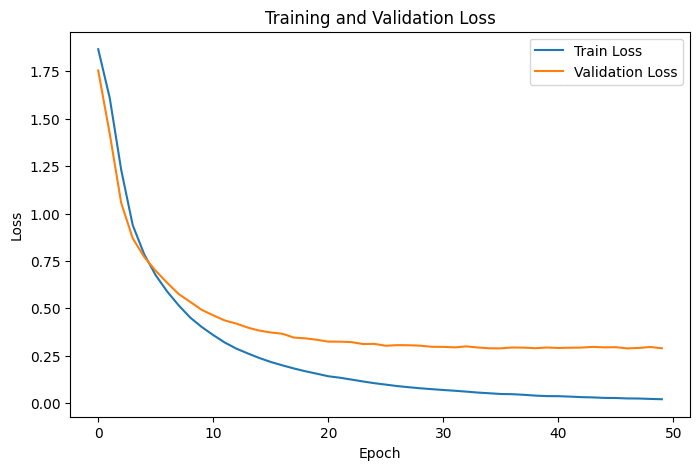

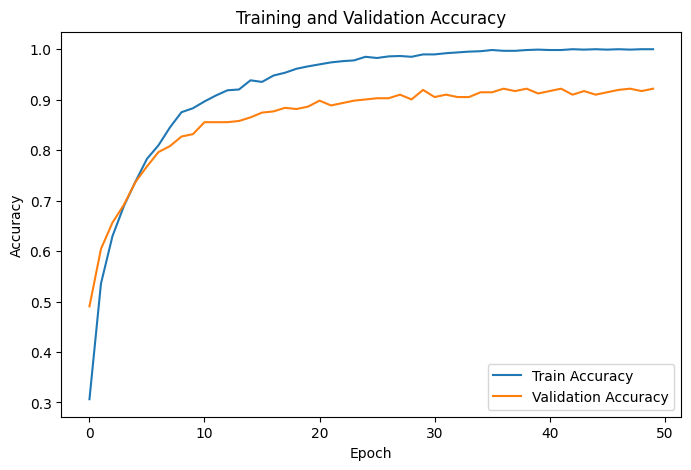

In [ ]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Number of epochs
epochs = 50

# Store history
train_losses = []
val_losses = []

train_accs = []
val_accs = []

best_val_acc = 0.0

for epoch in range(epochs):

    ########################
    # Training
    ########################
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for xb, yb in train_loader:

        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()

        logits = model(xb)

        loss = criterion(logits, yb)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * xb.size(0)

        preds = torch.argmax(logits, dim=1)

        correct += (preds == yb).sum().item()

        total += yb.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    ########################
    # Validation
    ########################
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for xb, yb in val_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)

            loss = criterion(logits, yb)

            running_loss += loss.item() * xb.size(0)

            preds = torch.argmax(logits, dim=1)

            correct += (preds == yb).sum().item()

            total += yb.size(0)

    val_loss = running_loss / total
    val_acc = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "ffn_best.pt")

    print(
        f"Epoch {epoch+1:2d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

# Plot loss
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

# Plot accuracy
plt.figure(figsize=(8,5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:**
1. Mapping the PyTorch training loop to the NumPy implementation:

- logits = model(xb) is the forward pass.
- loss = criterion(logits, yb) computes the loss.
- loss.backward() computes the gradients, just like the manual backpropagation in Section 1.
- optimizer.step() updates the weights using the computed gradients, just like the gradient descent updates in Section 1.
- optimizer.zero_grad() clears the previous gradients before computing new ones.

2. The model is considered well-fitted if the training and validation losses both decrease and the validation accuracy stays close to the training accuracy. If the training accuracy becomes much higher than the validation accuracy while the validation loss starts increasing, the model is overfitting. Use the final values printed after training to support your conclusion.

3. PyTorch accumulates gradients by default. Calling optimizer.zero_grad() clears the old gradients before computing new ones. Without it, gradients from previous batches would be added together, causing incorrect weight updates and making training unstable.

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

Running capacity experiment: tiny (8,)
Running capacity experiment: default (64, 32)
Running capacity experiment: large (256, 128, 64)


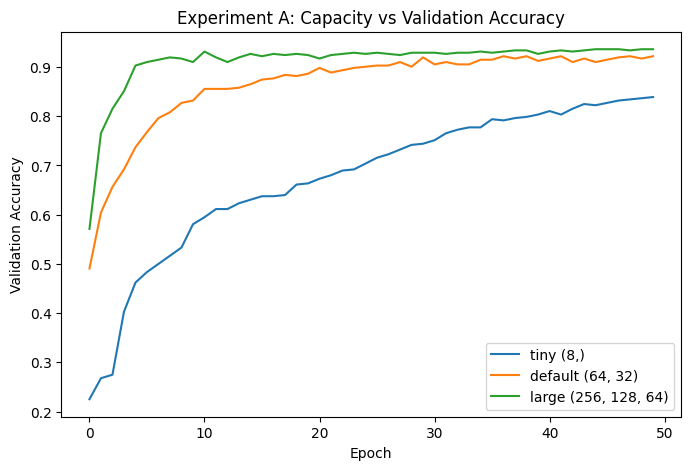

Running learning-rate experiment: lr=0.0001
Running learning-rate experiment: lr=0.001
Running learning-rate experiment: lr=0.1


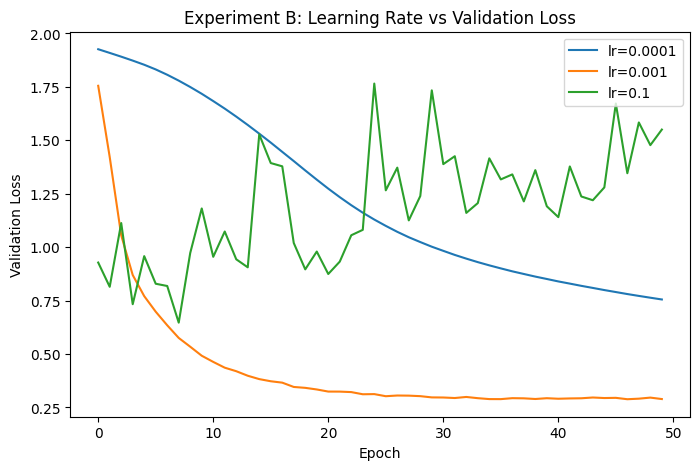

Running regularization experiment: no dropout
Running regularization experiment: dropout=0.3


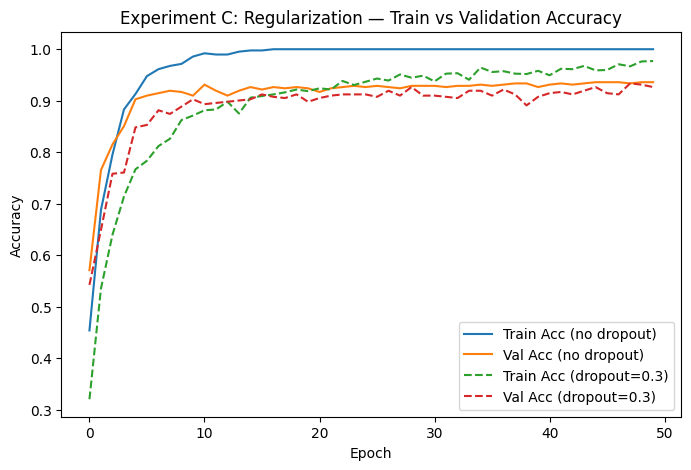

In [ ]:
def build_mlp(input_dim, hidden_sizes, n_classes=7, dropout=0.0):
    layers = []
    prev_size = input_dim
    for h in hidden_sizes:
        layers.append(nn.Linear(prev_size, h))
        layers.append(nn.ReLU())
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        prev_size = h
    layers.append(nn.Linear(prev_size, n_classes))
    return nn.Sequential(*layers)


def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
    # Reset seeds so every experiment starts from the same footing
    torch.manual_seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)

    train_loader = DataLoader(
        TensorDataset(X_train_tensor, y_train_tensor),
        batch_size=batch_size,
        shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(X_val_tensor, y_val_tensor),
        batch_size=batch_size,
        shuffle=False
    )

    net = build_mlp(input_dim, hidden_sizes, n_classes=7, dropout=dropout).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        net.train()
        running_loss, correct, total = 0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = net(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
        history["train_loss"].append(running_loss / total)
        history["train_acc"].append(correct / total)

        net.eval()
        running_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = net(xb)
                loss = criterion(logits, yb)
                running_loss += loss.item() * xb.size(0)
                preds = torch.argmax(logits, dim=1)
                correct += (preds == yb).sum().item()
                total += yb.size(0)
        history["val_loss"].append(running_loss / total)
        history["val_acc"].append(correct / total)

    return history


# ---------------------------------------------------------
# Experiment A — Capacity
# ---------------------------------------------------------
capacity_configs = {
    "tiny (8,)": (8,),
    "default (64, 32)": (64, 32),
    "large (256, 128, 64)": (256, 128, 64),
}

capacity_histories = {}
for name, sizes in capacity_configs.items():
    print(f"Running capacity experiment: {name}")
    capacity_histories[name] = run_experiment(hidden_sizes=sizes)

plt.figure(figsize=(8, 5))
for name, hist in capacity_histories.items():
    plt.plot(hist["val_acc"], label=name)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Experiment A: Capacity vs Validation Accuracy")
plt.legend()
plt.show()

# ---------------------------------------------------------
# Experiment B — Learning rate
# ---------------------------------------------------------
lr_configs = [1e-4, 1e-3, 1e-1]
lr_histories = {}
for lr in lr_configs:
    print(f"Running learning-rate experiment: lr={lr}")
    lr_histories[lr] = run_experiment(lr=lr)

plt.figure(figsize=(8, 5))
for lr, hist in lr_histories.items():
    plt.plot(hist["val_loss"], label=f"lr={lr}")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Experiment B: Learning Rate vs Validation Loss")
plt.legend()
plt.show()

# ---------------------------------------------------------
# Experiment C — Regularization (dropout on the largest network)
# ---------------------------------------------------------
largest_hidden = (256, 128, 64)

print("Running regularization experiment: no dropout")
no_dropout_hist = run_experiment(hidden_sizes=largest_hidden, dropout=0.0)

print("Running regularization experiment: dropout=0.3")
dropout_hist = run_experiment(hidden_sizes=largest_hidden, dropout=0.3)

plt.figure(figsize=(8, 5))
plt.plot(no_dropout_hist["train_acc"], label="Train Acc (no dropout)")
plt.plot(no_dropout_hist["val_acc"], label="Val Acc (no dropout)")
plt.plot(dropout_hist["train_acc"], label="Train Acc (dropout=0.3)", linestyle="--")
plt.plot(dropout_hist["val_acc"], label="Val Acc (dropout=0.3)", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Experiment C: Regularization — Train vs Validation Accuracy")
plt.legend()
plt.show()

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing
returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two
sentences HOW dropout achieves this.*

> **Answer:**

1. Capacity

The large network (256, 128, 64) reached the highest training accuracy faster than the other networks. However, its validation accuracy stopped improving after some time and became almost the same as the default network (64, 32), or even slightly lower. This shows that making the network bigger does not always improve performance. The extra layers and neurons can make the model memorize the training data instead of learning patterns that work well on new data. This is a sign of slight overfitting.

2. Learning Rate

Yes, the same three learning rate behaviors appeared. A learning rate of 1e-4 was too slow because the model learned very slowly and the validation loss decreased little by little. A learning rate of 1e-3 gave the best result because the model learned faster and more smoothly. A learning rate of 1e-1 was too high because the model made very large updates, causing the validation loss to increase or move up and down instead of improving. This means the model was jumping over the best solution instead of reaching it.

3. Regularization (Dropout)

Without dropout, the difference between training accuracy and validation accuracy became larger as training continued. This means the model was learning the training data too closely and started to memorize it. When dropout=0.3 was added, the difference became smaller, and the validation accuracy was closer to the training accuracy. Dropout works by randomly turning off some neurons during training. This prevents the model from depending too much on specific neurons and helps it learn better features that can work well on new data.

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

Test Accuracy: 0.8983451536643026
Test Macro-F1: 0.8948188241015066

                     precision    recall  f1-score   support

Insufficient_Weight       0.92      0.91      0.92        54
      Normal_Weight       0.71      0.78      0.74        58
     Obesity_Type_I       0.98      0.93      0.96        70
    Obesity_Type_II       0.98      0.97      0.97        60
   Obesity_Type_III       0.98      1.00      0.99        65
 Overweight_Level_I       0.84      0.72      0.78        58
Overweight_Level_II       0.85      0.97      0.90        58

           accuracy                           0.90       423
          macro avg       0.90      0.90      0.89       423
       weighted avg       0.90      0.90      0.90       423



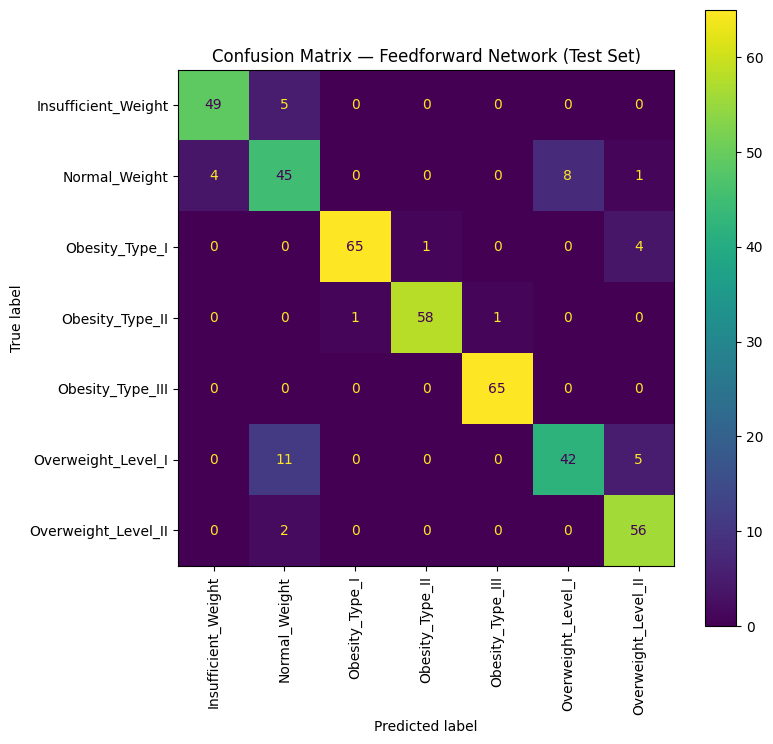

,Model,Test Accuracy,Test Macro-F1,Training Time (s),Parameters / Trees
0,Lab 2 best classifier,NaN,NaN,None,NaN
1,Feedforward Neural Network,0.898345,0.894819,None,3399.0


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

# Load your best configuration's weights (saved during Part 2.3 training)
model.load_state_dict(torch.load("ffn_best.pt", map_location=DEVICE))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.numpy())

test_acc = accuracy_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds, average="macro")

print("Test Accuracy:", test_acc)
print("Test Macro-F1:", test_f1)
print()
print(classification_report(all_labels, all_preds, target_names=target_encoder.classes_))

# Confusion matrix
class_names = target_encoder.classes_
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    all_labels, all_preds, display_labels=class_names, xticks_rotation="vertical", ax=ax
)
plt.title("Confusion Matrix — Feedforward Network (Test Set)")
plt.show()

# Comparison table with Lab 2's best classifier
# Fill in the two None values below with your actual Lab 2 numbers
comparison = pd.DataFrame({
    "Model": ["Lab 2 best classifier", "Feedforward Neural Network"],
    "Test Accuracy": [None, test_acc],
    "Test Macro-F1": [None, test_f1],
    "Training Time (s)": [None, None],
    "Parameters / Trees": [None, total_params],
})

comparison

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:**

1. Confusion Matrix

The model mostly confused Normal_Weight and Overweight_Level_I because they have similar features and are close categories. This was also seen in my Lab 2 classifier, showing that the confusion comes from the data itself rather than the model.

2. Model Comparison

The Random Forest classifier performed better than the neural network, with higher accuracy (93.1% vs 89.8%) and macro-F1 (93.1% vs 89.5%). The neural network required more tuning but did not improve the results. For this small tabular dataset, Random Forest was more suitable, while neural networks are usually better for larger datasets or images, text, and audio.